# 配套实践 04-01：比较 AE、VAE 与 MAE 的视觉表征

本练习使用人工生成的桌面目标图像，依次训练 AE、VAE 和简化 MAE。重点不是追求漂亮的重建，而是比较三种训练目标怎样约束潜在表示，并用一个简单位置读出任务检查表示中是否保留了目标位置。依赖：PyTorch、NumPy、Matplotlib；Google Colab 的 CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/04-visual-representation-learning/" target="_blank">在新标签页返回课程正文</a>

In [1]:
import numpy as np  # 保存训练曲线并辅助绘图
import matplotlib.pyplot as plt  # 绘制样本、重建结果和评价图
import torch  # 构造张量并训练三个小型模型
from torch import nn  # 使用线性层、激活函数和模块基类
torch.manual_seed(24)  # 固定数据、初始化和训练过程的随机性
np.random.seed(24)  # 固定 NumPy 侧的随机性
torch.set_num_threads(2)  # 限制 CPU 线程数量以适合在线环境

## 1. 构造带有位置标签的人工图像

每张 16×16 灰度图中都有一个亮色圆形目标，并叠加方向和强度不同的背景纹理。模型训练时只接收图像，不接收圆心坐标；坐标只在最后评价表示时使用。

In [2]:
image_size = 16  # 设置正方形人工图像的边长
sample_count = 480  # 设置训练集与测试集的总样本数
generator = torch.Generator().manual_seed(24)  # 创建独立且可重复的数据随机源
grid_y, grid_x = torch.meshgrid(torch.arange(image_size), torch.arange(image_size), indexing="ij")  # 建立像素坐标网格
images = torch.empty((sample_count, 1, image_size, image_size), dtype=torch.float32)  # 预留全部灰度图像
positions = torch.empty((sample_count, 2), dtype=torch.float32)  # 预留归一化目标圆心
for index in range(sample_count):  # 逐张生成带有不同目标和背景的图像
    center_x = int(torch.randint(3, 13, (1,), generator=generator).item())  # 随机选择目标水平位置
    center_y = int(torch.randint(3, 13, (1,), generator=generator).item())  # 随机选择目标垂直位置
    direction = int(torch.randint(0, 2, (1,), generator=generator).item())  # 随机选择横向或纵向背景纹理
    strength = float(torch.rand(1, generator=generator).item() * 0.18)  # 随机设置背景纹理强度
    coordinate = grid_x if direction == 0 else grid_y  # 根据方向选择生成纹理的坐标轴
    background = 0.08 + strength * (coordinate.float() / (image_size - 1))  # 生成平滑但与任务无关的背景
    noise = torch.randn((image_size, image_size), generator=generator) * 0.015  # 添加轻微传感器噪声
    image = (background + noise).clamp(0.0, 1.0)  # 把背景像素限制到有效灰度范围
    target_mask = (grid_x - center_x).square() + (grid_y - center_y).square() <= 4  # 找出半径为二的圆形目标
    image[target_mask] = 0.95  # 把目标区域设置为稳定亮度
    images[index, 0] = image  # 保存当前人工图像
    positions[index] = torch.tensor([center_x, center_y], dtype=torch.float32) / (image_size - 1)  # 保存归一化圆心
train_images = images[:400]  # 使用前四百张图训练视觉模型
test_images = images[400:]  # 使用剩余图像评价重建与表示
train_positions = positions[:400]  # 保存训练样本的位置读出标签
test_positions = positions[400:]  # 保存测试样本的位置读出标签
assert train_images.shape == (400, 1, 16, 16)  # 检查图像接口符合预期
assert test_positions.shape == (80, 2)  # 检查测试位置标签形状

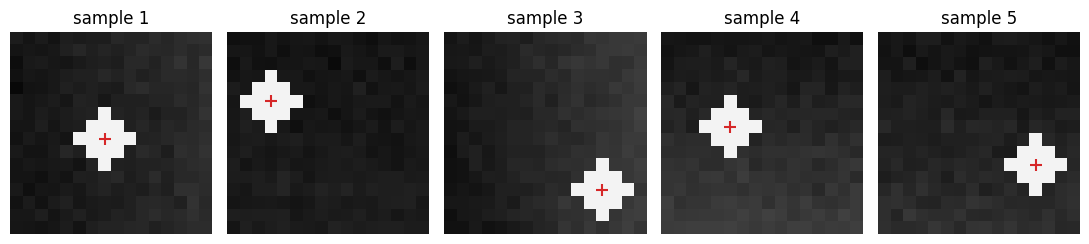

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))  # 创建五个样本的横向画布
for index, axis in enumerate(axes):  # 逐个显示人工图像和目标中心
    axis.imshow(train_images[index, 0], cmap="gray", vmin=0.0, vmax=1.0)  # 显示当前灰度图像
    pixel_position = train_positions[index].numpy() * (image_size - 1)  # 把归一化坐标还原为像素坐标
    axis.scatter(pixel_position[0], pixel_position[1], marker="+", color="tab:red", s=70)  # 标出只用于评价的真实圆心
    axis.set_title(f"sample {index + 1}")  # 标注当前样本编号
    axis.axis("off")  # 隐藏不必要的坐标刻度
plt.tight_layout()  # 调整子图间距
plt.show()  # 显示人工数据样例

**怎样理解结果：** 红色十字只是帮助我们检查数据，后续不会输入模型。目标位置和背景纹理都在变化，因此只看某一张图无法判断编码器最终会优先保存哪类信息；这取决于模型结构和训练损失。

## 2. 定义三种重建式模型

三种模型都使用八维潜在表示。AE 产生确定向量；VAE 产生均值和对数方差；简化 MAE 同时接收被遮挡图像和可见位置，只在被遮挡像素上计算重建误差。

In [4]:
flat_size = image_size * image_size  # 计算展平图像的输入维度
latent_size = 8  # 为三种模型统一设置八维潜在表示
class Encoder(nn.Module):  # 定义 AE 使用的确定性编码器
    def __init__(self, input_size=flat_size):  # 接收编码器输入维度
        super().__init__()  # 初始化 PyTorch 模块基类
        self.network = nn.Sequential(nn.Linear(input_size, 96), nn.ReLU(), nn.Linear(96, latent_size))  # 把输入压缩成潜在向量
    def forward(self, values):  # 定义编码器前向计算
        return self.network(values)  # 返回每个样本的八维表示
class Decoder(nn.Module):  # 定义三种模型共用结构的解码器
    def __init__(self):  # 创建潜在向量到图像的映射
        super().__init__()  # 初始化 PyTorch 模块基类
        self.network = nn.Sequential(nn.Linear(latent_size, 96), nn.ReLU(), nn.Linear(96, flat_size), nn.Sigmoid())  # 把潜在向量恢复为有效灰度值
    def forward(self, latent):  # 定义解码器前向计算
        return self.network(latent)  # 返回展平后的重建图像
class Autoencoder(nn.Module):  # 组合确定性编码器与解码器
    def __init__(self):  # 创建 AE 的两个组成部分
        super().__init__()  # 初始化 PyTorch 模块基类
        self.encoder = Encoder()  # 创建完整图像编码器
        self.decoder = Decoder()  # 创建潜在向量解码器
    def forward(self, flat_image):  # 定义 AE 的重建路径
        latent = self.encoder(flat_image)  # 把完整图像压缩为确定向量
        return self.decoder(latent), latent  # 返回重建结果和潜在表示
class VariationalAutoencoder(nn.Module):  # 定义输出潜在分布参数的 VAE
    def __init__(self):  # 创建共享特征层、分布头和解码器
        super().__init__()  # 初始化 PyTorch 模块基类
        self.shared = nn.Sequential(nn.Linear(flat_size, 96), nn.ReLU())  # 从完整图像提取共享特征
        self.mean_head = nn.Linear(96, latent_size)  # 输出潜在高斯分布的均值
        self.logvar_head = nn.Linear(96, latent_size)  # 输出潜在高斯分布的对数方差
        self.decoder = Decoder()  # 创建潜在样本解码器
    def encode(self, flat_image):  # 计算潜在分布的两个参数
        shared = self.shared(flat_image)  # 提取分布头共用的图像特征
        return self.mean_head(shared), self.logvar_head(shared)  # 返回均值和对数方差
    def forward(self, flat_image):  # 定义带重参数化的 VAE 前向计算
        mean, logvar = self.encode(flat_image)  # 根据输入得到潜在分布参数
        noise = torch.randn_like(mean)  # 从标准高斯分布采样独立噪声
        latent = mean + torch.exp(0.5 * logvar) * noise  # 使用重参数化得到可求导的潜在样本
        return self.decoder(latent), mean, logvar  # 返回重建和分布参数
class MaskedAutoencoder(nn.Module):  # 定义面向像素遮挡的简化 MAE
    def __init__(self):  # 创建同时读取图像与可见掩码的编码器
        super().__init__()  # 初始化 PyTorch 模块基类
        self.encoder = Encoder(flat_size * 2)  # 让编码器区分可见零值与被遮挡位置
        self.decoder = Decoder()  # 创建遮挡区域解码器
    def forward(self, flat_image, visible_mask):  # 定义 MAE 的遮挡重建路径
        encoder_input = torch.cat([flat_image * visible_mask, visible_mask], dim=1)  # 合并可见像素与掩码信息
        latent = self.encoder(encoder_input)  # 根据可见内容形成潜在表示
        return self.decoder(latent), latent  # 返回完整预测和潜在表示
ae_model = Autoencoder()  # 创建待训练的 AE
vae_model = VariationalAutoencoder()  # 创建待训练的 VAE
mae_model = MaskedAutoencoder()  # 创建待训练的简化 MAE

## 3. 在同一批图像上训练

AE 使用整图均方误差；VAE 在重建误差之外加入较小的 KL 正则；MAE 每次随机隐藏约 55% 像素，并只评价隐藏区域。三条损失的数值含义不同，因此曲线只能用于观察各自是否稳定下降，不能直接用高低判断哪种方法更好。

In [5]:
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=2e-3)  # 创建 AE 参数优化器
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=2e-3)  # 创建 VAE 参数优化器
mae_optimizer = torch.optim.Adam(mae_model.parameters(), lr=2e-3)  # 创建 MAE 参数优化器
history = {"AE": [], "VAE": [], "MAE": []}  # 分别保存三种训练目标的轮次损失
batch_size = 64  # 设置每次更新使用的图像数量
epoch_count = 45  # 设置轻量实验的训练轮数
for epoch in range(epoch_count):  # 多次遍历训练图像以优化三种模型
    order = torch.randperm(len(train_images))  # 每轮重新打乱训练样本
    epoch_losses = {"AE": [], "VAE": [], "MAE": []}  # 收集当前轮的 batch 损失
    for start in range(0, len(train_images), batch_size):  # 按小批量读取训练图像
        batch = train_images[order[start:start + batch_size]].flatten(1)  # 取出并展平当前图像 batch
        ae_reconstruction, _ = ae_model(batch)  # 使用 AE 重建完整图像
        ae_loss = (ae_reconstruction - batch).square().mean()  # 计算 AE 的整图像素误差
        ae_optimizer.zero_grad()  # 清除 AE 上一次更新留下的梯度
        ae_loss.backward()  # 计算 AE 编码器和解码器梯度
        ae_optimizer.step()  # 根据当前梯度更新 AE 参数
        vae_reconstruction, mean, logvar = vae_model(batch)  # 使用 VAE 采样潜变量并重建图像
        vae_reconstruction_loss = (vae_reconstruction - batch).square().mean()  # 计算 VAE 重建误差
        vae_kl = -0.5 * (1.0 + logvar - mean.square() - logvar.exp()).sum(dim=1).mean()  # 计算后验到标准高斯的 KL 项
        vae_loss = vae_reconstruction_loss + 0.01 * vae_kl  # 用较小权重平衡重建和潜空间正则
        vae_optimizer.zero_grad()  # 清除 VAE 上一次更新留下的梯度
        vae_loss.backward()  # 通过重参数化路径计算 VAE 梯度
        vae_optimizer.step()  # 根据当前梯度更新 VAE 参数
        visible_mask = (torch.rand_like(batch) > 0.55).float()  # 随机保留约百分之四十五的输入像素
        mae_reconstruction, _ = mae_model(batch, visible_mask)  # 根据可见像素预测完整图像
        hidden_mask = 1.0 - visible_mask  # 找出本次需要恢复的隐藏像素
        mae_loss = ((mae_reconstruction - batch).square() * hidden_mask).sum() / hidden_mask.sum().clamp_min(1.0)  # 只计算隐藏区域误差
        mae_optimizer.zero_grad()  # 清除 MAE 上一次更新留下的梯度
        mae_loss.backward()  # 计算遮挡重建目标产生的梯度
        mae_optimizer.step()  # 根据当前梯度更新 MAE 参数
        epoch_losses["AE"].append(ae_loss.item())  # 保存当前 AE batch 损失
        epoch_losses["VAE"].append(vae_loss.item())  # 保存当前 VAE batch 损失
        epoch_losses["MAE"].append(mae_loss.item())  # 保存当前 MAE batch 损失
    for name in history:  # 汇总三种模型当前轮的平均损失
        history[name].append(float(np.mean(epoch_losses[name])))  # 保存可绘制的轮次损失
    if epoch in {0, 9, 24, 44}:  # 只在关键轮次报告训练进度
        print(f"epoch={epoch + 1:02d} | AE={history['AE'][-1]:.4f} | VAE={history['VAE'][-1]:.4f} | MAE={history['MAE'][-1]:.4f}")  # 输出三条训练曲线的当前值

epoch=01 | AE=0.1335 | VAE=0.1288 | MAE=0.1202
epoch=10 | AE=0.0339 | VAE=0.0351 | MAE=0.0326
epoch=25 | AE=0.0231 | VAE=0.0340 | MAE=0.0306
epoch=45 | AE=0.0101 | VAE=0.0333 | MAE=0.0199


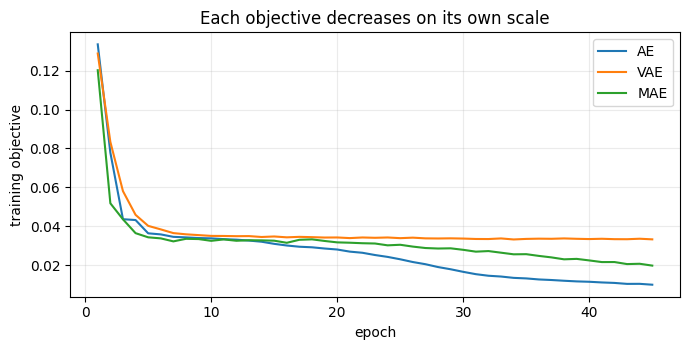

In [6]:
fig, axis = plt.subplots(figsize=(7, 3.6))  # 创建简洁的训练曲线画布
for name, values in history.items():  # 逐条绘制三种方法的轮次损失
    axis.plot(np.arange(1, epoch_count + 1), values, label=name)  # 绘制当前方法的下降趋势
axis.set_xlabel("epoch")  # 标注横轴为训练轮数
axis.set_ylabel("training objective")  # 标注纵轴为各自训练目标
axis.set_title("Each objective decreases on its own scale")  # 强调不同曲线不能只比绝对大小
axis.legend()  # 显示三种方法对应的颜色
axis.grid(alpha=0.25)  # 添加较淡网格帮助读取趋势
plt.tight_layout()  # 调整图像边距
plt.show()  # 显示训练曲线

**怎样理解结果：** 三条曲线都下降，说明优化器正在满足各自目标。VAE 曲线包含 KL 项，MAE 只统计隐藏像素，它们和 AE 的整图误差不是同一把尺子。这里不能得出“最低曲线对应最好表征”的结论。

## 4. 先看一个重建案例

为了避免一次展示过多结果，下面只选择一张测试图。MAE 的输入保留固定比例像素，黑色位置表示当前不可见；解码器仍需预测完整图像。

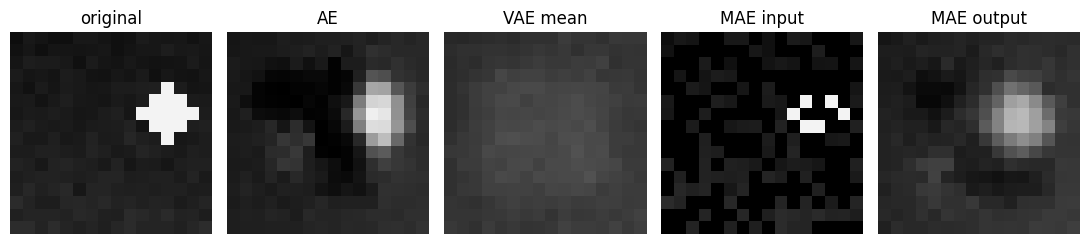

In [7]:
ae_model.eval()  # 把 AE 切换到稳定的评估模式
vae_model.eval()  # 把 VAE 切换到稳定的评估模式
mae_model.eval()  # 把 MAE 切换到稳定的评估模式
example = test_images[0:1].flatten(1)  # 选取一张未参与训练的测试图像
display_generator = torch.Generator().manual_seed(8)  # 固定展示用遮挡图案
example_visible = (torch.rand(example.shape, generator=display_generator) > 0.55).float()  # 为示例创建可见像素掩码
with torch.no_grad():  # 评估时关闭梯度记录以减少开销
    ae_output, _ = ae_model(example)  # 得到 AE 的确定性重建
    vae_mean, _ = vae_model.encode(example)  # 读取 VAE 后验均值作为稳定表示
    vae_output = vae_model.decoder(vae_mean)  # 使用均值而不是随机样本生成展示重建
    mae_output, _ = mae_model(example, example_visible)  # 根据部分可见像素得到 MAE 重建
panels = [example, ae_output, vae_output, example * example_visible, mae_output]  # 按教学顺序组织五幅图
titles = ["original", "AE", "VAE mean", "MAE input", "MAE output"]  # 为五幅结果准备简短标题
fig, axes = plt.subplots(1, 5, figsize=(11, 2.4))  # 创建单行结果对比画布
for panel, title, axis in zip(panels, titles, axes):  # 逐幅绘制输入和重建
    axis.imshow(panel.reshape(image_size, image_size), cmap="gray", vmin=0.0, vmax=1.0)  # 使用统一灰度范围显示结果
    axis.set_title(title)  # 标注当前图像来源
    axis.axis("off")  # 隐藏像素坐标刻度
plt.tight_layout()  # 调整五幅图之间的距离
plt.show()  # 显示重建案例

**怎样理解结果：** AE 可以直接利用完整输入进行压缩和恢复；VAE 还要让潜在分布接近先验。如果 VAE 像本次结果一样趋向接近平均灰度的模糊图，说明 KL 约束可能让不同输入的潜变量过于相似，解码器没有充分利用位置线索，这是后验坍缩的直观迹象。MAE 只看到稀疏像素，输出更依赖训练数据中的形状规律。单张重建的清晰度仍不能说明哪种表示最适合机器人定位，所以还要直接检查位置能否被读出。

## 5. 冻结编码器并读取目标位置

下面不再修改三个编码器，只用最简单的线性最小二乘关系把八维表示映射到圆心坐标。柱形越低，说明目标位置越容易从当前表示中读取；这比单看重建图更接近机器人后续需要的空间信息。

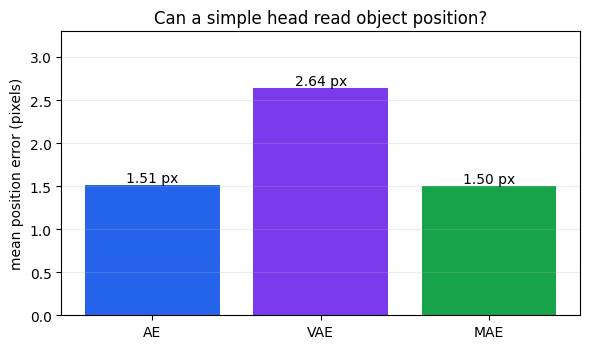

In [8]:
def append_bias(features):  # 为线性位置读出增加常数偏置列
    ones = torch.ones((len(features), 1), dtype=features.dtype)  # 创建与样本数量一致的常数列
    return torch.cat([features, ones], dim=1)  # 返回带偏置输入的表示矩阵
def position_error(train_features, test_features):  # 用冻结表示拟合并评价线性位置读出
    weights = torch.linalg.lstsq(append_bias(train_features), train_positions).solution  # 求解训练集上的最小二乘映射
    predicted = append_bias(test_features) @ weights  # 使用同一映射预测测试圆心
    pixel_distance = torch.linalg.vector_norm((predicted - test_positions) * (image_size - 1), dim=1)  # 转换成直观像素距离
    return float(pixel_distance.mean().item())  # 返回全部测试样本的平均误差
with torch.no_grad():  # 冻结三个编码器并提取训练与测试表示
    train_flat = train_images.flatten(1)  # 展平训练图像以输入全连接编码器
    test_flat = test_images.flatten(1)  # 展平测试图像以输入全连接编码器
    ae_train_features = ae_model.encoder(train_flat)  # 提取 AE 训练表示
    ae_test_features = ae_model.encoder(test_flat)  # 提取 AE 测试表示
    vae_train_features, _ = vae_model.encode(train_flat)  # 使用 VAE 均值作为训练表示
    vae_test_features, _ = vae_model.encode(test_flat)  # 使用 VAE 均值作为测试表示
    train_visible = torch.ones_like(train_flat)  # 用全可见掩码读取 MAE 训练表示
    test_visible = torch.ones_like(test_flat)  # 用全可见掩码读取 MAE 测试表示
    _, mae_train_features = mae_model(train_flat, train_visible)  # 提取 MAE 训练表示
    _, mae_test_features = mae_model(test_flat, test_visible)  # 提取 MAE 测试表示
errors = [position_error(ae_train_features, ae_test_features), position_error(vae_train_features, vae_test_features), position_error(mae_train_features, mae_test_features)]  # 计算三种表示的位置误差
fig, axis = plt.subplots(figsize=(6, 3.6))  # 创建简单的位置误差柱形图
bars = axis.bar(["AE", "VAE", "MAE"], errors, color=["#2563eb", "#7c3aed", "#16a34a"])  # 对比三种冻结表示
axis.bar_label(bars, fmt="%.2f px")  # 在柱形上标出平均像素误差
axis.set_ylabel("mean position error (pixels)")  # 说明纵轴的实际单位
axis.set_title("Can a simple head read object position?")  # 说明评价问题
axis.set_ylim(0.0, max(errors) * 1.25)  # 为数值标签保留顶部空间
axis.grid(axis="y", alpha=0.25)  # 添加较淡横向参考线
plt.tight_layout()  # 调整画布边距
plt.show()  # 显示位置读取结果

**怎样理解结果：** 柱形图回答的是“经过当前训练后，圆心位置是否容易从八维表示中读出”，而不是给三种方法排永久名次。结果会随遮挡比例、KL 权重、潜在维度和数据分布变化。若一种方法重建更清晰却位置误差更大，正好说明像素质量与机器人任务可用性并不等价。

## 结论与练习

三种方法都能从无人工类别标签的图像中获得训练信号，但它们对表示施加的约束不同。尝试把 VAE 的 KL 权重从 `0.01` 分别改为 `0.001` 和 `0.1`，观察减弱与加强正则后重建和位置误差怎样变化；也可以把 MAE 的隐藏比例从 55% 改为 75%。不要只问哪幅图更清晰，还要解释表示中哪类信息变得更容易或更难读取。